In [1]:
import sys
import platform
from os.path import join, exists, abspath, dirname
from os import getcwd, makedirs, remove
from glob import glob

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps, cm
from matplotlib import colors as mcolors
import scipy
from scipy.stats import kendalltau
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from scipy.io import loadmat
from sklearn.metrics import r2_score
from statsmodels.stats.anova import AnovaRM
import seaborn as sns
import h5py

from tqdm import tqdm

In [2]:
import nibabel as nb
from nilearn import plotting, image
from nipype.interfaces import fsl

In [3]:
from nilearn.mass_univariate import permuted_ols

In [4]:
dir_current = getcwd().replace('\\','/')

tmp = dir_current.split('/')
idx = [ii for ii, s in enumerate(tmp) if s=='github'][0]

dir_git = '/'.join(tmp[:idx+1])
dir_git

'/home/sungbeenpark/github'

In [5]:
dname = join(dir_git,'nitools')
sys.path.append(dname)
import nitools as nt

In [6]:
dname = join(dir_git,'SUITPy')
sys.path.append(dname)
import SUITPy as suit

In [7]:
dname = join(dir_git)
sys.path.append(dname)
import surfAnalysisPy as surf

In [8]:
dname = join(dir_git,'Functional_Fusion')
sys.path.append(dname)
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

In [9]:
dname = join(dir_git,'AnatSearchlight')
sys.path.append(dname)
import AnatSearchlight.searchlight as sl

In [10]:
dname = abspath(join(dir_git,'PcmPy'))
sys.path.append(dname)
import PcmPy as pcm

In [11]:
dname = join(dir_git,'SeqSpatialSupp_fMRI')
sys.path.append(dname)
from SSS import deal_spm
from SSS import util as su
from SSS import stat as sstat
from SSS import plot as splt
from SSS import image as simage
from SSS import glmsingle as ssingle

---

In [12]:
hem = 'L'

In [13]:
list_sn = su.get_list_sn()

---

In [14]:
dir_surf = join(ssingle.get_dir_glmsingle(),'surfaceWB')
dir_surf

'/mnt/f/SeqSpatialSupp_fMRI/GLMsingle/surfaceWB'

In [15]:
dir_group = join(dir_surf,'group')

In [16]:
glm = 1
dir_work = join(dir_surf,'glm_%1d'%glm)
dir_work

'/mnt/f/SeqSpatialSupp_fMRI/GLMsingle/surfaceWB/glm_1'

---

### Load individual dataset

In [17]:
model = 'first_finger'

In [18]:
fname = join(dir_work,'cifti.%s.glm_%1d.searchlight.mean_dist.%s.dscalar.nii'%(hem,glm,model))
dataset = nb.load(fname)
N = dataset.shape[0]
dataset.shape

(12, 32492)

In [19]:
thresh = sstat.convert_alpha_to_tval(alpha=0.05, df=N-1, alternative='greater')
thresh

np.float64(2.200985160082949)

---

### surface adjacency

In [20]:
fname = join(dir_git,'fs_LR_32/fs_LR.32k.L.midthickness.surf.gii')
exists(fname)

True

In [21]:
gii = nb.load(fname)
coords = gii.darrays[0].data
faces = gii.darrays[1].data
print(coords.shape, faces.shape)

(32492, 3) (64980, 3)


In [31]:
V = coords.shape[0]
adj = [[] for _ in range(V)]
for f in faces:
    a, b, c = f
    adj[a].extend([b,c])
    adj[b].extend([a,c])
    adj[c].extend([a,b])

---
---

### sign-flip permutation

In [1]:
X = dataset.get_fdata()
n_perm = 5000
max_cluster_masses = []

for _ in tqdm(range(n_perm)):
    signs = np.random.choice([1, -1], size=(12, 1))
    X_perm = X * signs

    t_perm, _ = ttest_1samp(X_perm, popmean=0, axis=0, alternative='greater')

    supra_perm = t_perm > thresh

    # cluster detection (same as above)
    visited = np.zeros(V, dtype=bool)
    max_mass = 0

    for v in np.where(supra_perm)[0]:
        if visited[v]:
            continue
        stack = [v]
        cluster = []
        while stack:
            u = stack.pop()
            if visited[u] or not supra_perm[u]:
                continue
            visited[u] = True
            cluster.append(u)
            for w in adj[u]:
                if not visited[w] and supra_perm[u]:
                    stack.append(w)

        if len(cluster) > 0:
            ## calucatie the mass
            mass = np.sum(t_perm[cluster])
            max_mass = max(max_mass, mass)

    max_cluster_masses.append(max_mass)

In [ ]:
max_cluster_masses = np.array(max_cluster_masses)
np.save(join(dir_work,'max_cluster_masses.%s'%model), max_cluster_masses)

---
---

#### load `max_cluster_masses`

(5000,)


(0.0, 2500.0)

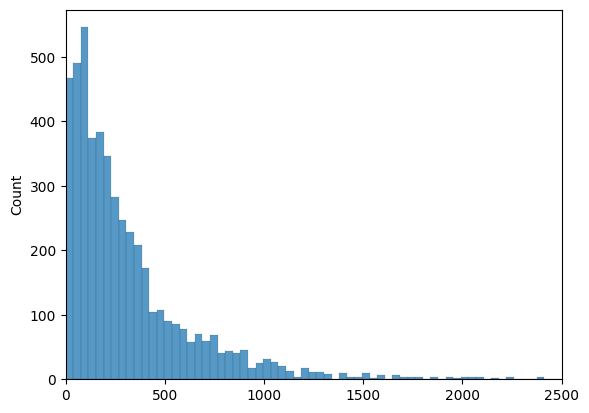

In [23]:
max_cluster_masses = np.load(join(dir_work,'max_cluster_masses.npy'))
print(max_cluster_masses.shape)
g = sns.histplot(max_cluster_masses)
g.set_xlim(0,2500)

---

### t-map

In [26]:
tval, pval = ttest_1samp(dataset.get_fdata(), popmean=0, axis=0, alternative='greater')
tval.shape

(32492,)

In [27]:
border, brdr = simage.get_border(dir_git=dir_git, atlas='sulcus')

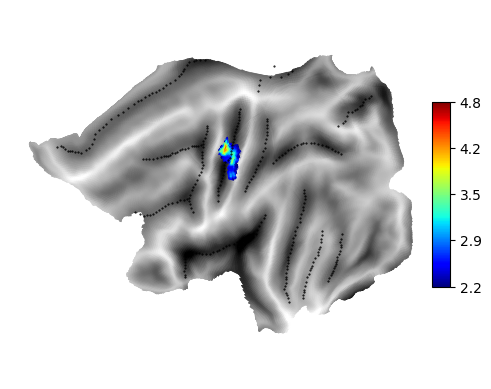

In [28]:
fig, ax = plt.subplots()
plt.sca(ax)
data = np.copy(tval)
data[data<thresh] = np.nan
g = surf.plot.plotmap(
    data=data,
    surf='fs32k_%s'%hem,
    alpha=1,
    cmap=cm.jet, colorbar=True,
    # cscale=[0.0019, 0.23],
    # threshold=thresh,
    borders=border, bordercolor='black', bordersize=1,
    overlay_type='func', render='matplotlib',
)

In [24]:
# 1. Helper: DFS-based cluster detection
def find_clusters(supra, adj):
    """
    supra: boolean array (V,)
    adj: adjacency list, list of lists
    """
    V = len(supra)
    visited = np.zeros(V, dtype=bool)
    clusters = []

    for v in np.where(supra)[0]:
        v = int(v)
        if visited[v]:
            continue
        stack = [v]
        cluster = []
        while stack:
            u = stack.pop()
            if visited[u] or not supra[u]:
                continue
            visited[u] = True
            cluster.append(u)
            for w in adj[u]:
                if not visited[w] and supra[w]:
                    stack.append(w)
        if len(cluster) > 0:
            clusters.append(cluster)

    return clusters

In [25]:
# # example: 0-1-2 | 3-4-5 | 6-7 | 8
# adj = { 0:[1], 1:[0, 2], 2:[1], 3:[4], 4:[3,5], 5:[4], 6:[7], 7:[6], 8:[] }
# # vertex 2 and 7 < thresh
# supra = np.array([True, True, False, True, True, True, True, False, True])
# # 함수 실행
# clusters = find_clusters(supra, adj)
# print("Detected clusters:", clusters)

Detected clusters: [[0, 1], [3, 4, 5], [6], [8]]


In [32]:
supra = tval > thresh
clusters = find_clusters(supra, adj)
# cluster mass 계산
real_masses = [np.sum(tval[c]) for c in clusters]

In [38]:
# 실제 cluster의 p-value 계산
null_dist = max_cluster_masses
pvals = []
for mass in real_masses:
    p = np.mean(null_dist >= mass)
    pvals.append(p)
pvals

[np.float64(0.123)]

In [43]:
# corrected map 생성
alpha = 0.05
corrected = np.zeros_like(tval)
for cluster, p in zip(clusters, pvals):
    if p < alpha:
        corrected[cluster] = t_real[cluster]
corrected.sum()

np.float64(0.0)

In [ ]:
# fig.savefig(
#     join(su.get_dir_root(),'RDM_flat.%s.png'%model),
#     dpi=300, facecolor=[1,1,1,1], bbox_inches = "tight"
# )

---

---